In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statistics import mean, stdev

In [2]:
sns.set_style('darkgrid')
cmap=sns.light_palette("seagreen",as_cmap=True)
pd.set_option('display.float_format','{:.4f}'.format)

In [3]:
unfair = pd.read_csv('../benchmark/balanced-stroke-result/unfair_lr-100.csv', index_col=0)
zhang = pd.read_csv('../benchmark/balanced-stroke-result/zhang-100.csv', index_col=0)

In [4]:
unfair = unfair.drop([0,1,2,3,4], axis=0)
unfair

,model_name,cv_seed,clas_acc,dp,deqodds,deqopp,trade_dp,trade_deqodds,trade_deqopp,TN_a0,FP_a0,FN_a0,TP_a0,TN_a1,FP_a1,FN_a1,TP_a1
5,UnfairLR,13,0.9094,0.7580,0.9378,0.9099,0.8268,0.9234,0.9097,805.0000,38.0000,94.0000,432.0000,522.0000,45.0000,78.0000,802.0000
6,UnfairLR,29,0.8977,0.7658,0.9279,0.9118,0.8265,0.9126,0.9047,740.0000,58.0000,87.0000,445.0000,508.0000,75.0000,68.0000,835.0000
7,UnfairLR,42,0.8995,0.7510,0.9184,0.8846,0.8186,0.9088,0.8920,800.0000,33.0000,114.0000,420.0000,522.0000,50.0000,86.0000,791.0000
8,UnfairLR,55,0.8977,0.7777,0.9447,0.9324,0.8334,0.9206,0.9147,740.0000,67.0000,71.0000,413.0000,548.0000,79.0000,71.0000,827.0000
9,UnfairLR,73,0.9070,0.7482,0.9188,0.8796,0.8200,0.9128,0.8931,780.0000,19.0000,113.0000,400.0000,554.0000,39.0000,91.0000,820.0000


In [5]:
zhang

,model_name,cv_seed,clas_acc,dp,deqodds,deqopp,trade_dp,trade_deqodds,trade_deqopp,TN_a0,FP_a0,FN_a0,TP_a0,TN_a1,FP_a1,FN_a1,TP_a1
0,Zhang4DP,13,0.9013,0.7587,0.9346,0.8954,0.8239,0.9176,0.8983,816.0000,27.0000,116.0000,410.0000,534.0000,33.0000,102.0000,778.0000
1,Zhang4DP,29,0.8878,0.7512,0.9082,0.8701,0.8138,0.8979,0.8788,734.0000,64.0000,108.0000,424.0000,505.0000,78.0000,66.0000,837.0000
2,Zhang4DP,42,0.8910,0.7464,0.9097,0.8675,0.8123,0.9002,0.8791,777.0000,56.0000,114.0000,420.0000,506.0000,66.0000,71.0000,806.0000
3,Zhang4DP,55,0.8878,0.7583,0.9196,0.9011,0.8179,0.9034,0.8944,736.0000,71.0000,84.0000,400.0000,533.0000,94.0000,67.0000,831.0000
4,Zhang4DP,73,0.8920,0.7530,0.9172,0.8886,0.8167,0.9045,0.8903,752.0000,47.0000,105.0000,408.0000,526.0000,67.0000,85.0000,826.0000
5,Zhang4EqOdds,13,0.9016,0.7599,0.9360,0.8969,0.8247,0.9185,0.8993,809.0000,34.0000,111.0000,415.0000,530.0000,37.0000,95.0000,785.0000
6,Zhang4EqOdds,29,0.8892,0.7524,0.9102,0.8761,0.8151,0.8996,0.8826,737.0000,61.0000,106.0000,426.0000,506.0000,77.0000,68.0000,835.0000
7,Zhang4EqOdds,42,0.8885,0.7577,0.9204,0.8816,0.8179,0.9042,0.8851,784.0000,49.0000,118.0000,416.0000,515.0000,57.0000,90.0000,787.0000
8,Zhang4EqOdds,55,0.8885,0.7520,0.9129,0.8903,0.8145,0.9005,0.8894,747.0000,60.0000,93.0000,391.0000,540.0000,87.0000,74.0000,824.0000
9,Zhang4EqOdds,73,0.8977,0.7625,0.9297,0.8957,0.8246,0.9134,0.8967,762.0000,37.0000,107.0000,406.0000,544.0000,49.0000,95.0000,816.0000


## Acc mean and std

In [6]:
unfair_acc = unfair.groupby(['model_name'])['clas_acc'].agg([mean, stdev])
zhang_acc = zhang.groupby(['model_name'])['clas_acc'].agg([mean, stdev])

In [7]:
acc = pd.concat([unfair_acc, zhang_acc])
acc = acc.reset_index()
acc = acc.rename(columns={'index': 'model_name'})
acc

,model_name,mean,stdev
0,UnfairLR,0.9023,0.0055
1,Zhang4DP,0.8920,0.0055
2,Zhang4EqOdds,0.8931,0.0062
3,Zhang4EqOpp,0.8827,0.0075


In [8]:
names = acc['model_name'].to_list()
for i in range(len(names)):
    if isinstance(names[i], tuple):
        names[i] = '-'.join([str(value) for value in names[i]])

names

['UnfairLR', 'Zhang4DP', 'Zhang4EqOdds', 'Zhang4EqOpp']

In [9]:
acc['model_name'] = names
acc

,model_name,mean,stdev
0,UnfairLR,0.9023,0.0055
1,Zhang4DP,0.8920,0.0055
2,Zhang4EqOdds,0.8931,0.0062
3,Zhang4EqOpp,0.8827,0.0075


In [10]:
print((acc['mean'].round(4).astype(str) + ' $\pm$ ' + acc['stdev'].round(4).astype(str)).to_string(index=False))

0.9023 $\pm$ 0.0055
 0.892 $\pm$ 0.0055
0.8931 $\pm$ 0.0062
0.8827 $\pm$ 0.0075


## Fairness mean and std

In [11]:
unfair_dp = unfair.groupby(['model_name'])['dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['dp'].agg([mean, stdev])

In [12]:
dp = pd.concat([unfair_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,UnfairLR,0.7601,0.0120
1,Zhang4DP,0.7535,0.0052
2,Zhang4EqOdds,0.7569,0.0046
3,Zhang4EqOpp,0.7679,0.0070


In [13]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

 0.7601 $\pm$ 0.012
0.7535 $\pm$ 0.0052
0.7569 $\pm$ 0.0046
 0.7679 $\pm$ 0.007


In [14]:
unfair_deqodds = unfair.groupby(['model_name'])['deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['deqodds'].agg([mean, stdev])

In [15]:
deqodds = pd.concat([unfair_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,UnfairLR,0.9295,0.0116
1,Zhang4DP,0.9179,0.0105
2,Zhang4EqOdds,0.9218,0.0109
3,Zhang4EqOpp,0.9285,0.0101


In [16]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.9295 $\pm$ 0.0116
0.9179 $\pm$ 0.0105
0.9218 $\pm$ 0.0109
0.9285 $\pm$ 0.0101


In [17]:
unfair_deqopp = unfair.groupby(['model_name'])['deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['deqopp'].agg([mean, stdev])

In [18]:
deqopp = pd.concat([unfair_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,UnfairLR,0.9037,0.0216
1,Zhang4DP,0.8845,0.0151
2,Zhang4EqOdds,0.8881,0.0090
3,Zhang4EqOpp,0.8827,0.0206


In [19]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.9037 $\pm$ 0.0216
0.8845 $\pm$ 0.0151
 0.8881 $\pm$ 0.009
0.8827 $\pm$ 0.0206


## Trade-offs mean and std

In [20]:
unfair_trade_dp = unfair.groupby(['model_name'])['trade_dp'].agg([mean, stdev])
zhang_trade_dp = zhang.groupby(['model_name'])['trade_dp'].agg([mean, stdev])

In [21]:
trade_dp = pd.concat([unfair_trade_dp, zhang_trade_dp])
trade_dp = trade_dp.reset_index()
trade_dp = trade_dp.rename(columns={'index': 'model_name'})
trade_dp['model_name'] = names
trade_dp

,model_name,mean,stdev
0,UnfairLR,0.8251,0.0060
1,Zhang4DP,0.8169,0.0045
2,Zhang4EqOdds,0.8194,0.0050
3,Zhang4EqOpp,0.8213,0.0054


In [22]:
print((trade_dp['mean'].round(4).astype(str) + ' $\pm$ ' + trade_dp['stdev'].round(4).astype(str)).to_string(index=False))

 0.8251 $\pm$ 0.006
0.8169 $\pm$ 0.0045
 0.8194 $\pm$ 0.005
0.8213 $\pm$ 0.0054


In [23]:
unfair_trade_deqodds = unfair.groupby(['model_name'])['trade_deqodds'].agg([mean, stdev])
zhang_trade_deqodds = zhang.groupby(['model_name'])['trade_deqodds'].agg([mean, stdev])

In [24]:
trade_deqodds = pd.concat([unfair_trade_deqodds, zhang_trade_deqodds])
trade_deqodds = trade_deqodds.reset_index()
trade_deqodds = trade_deqodds.rename(columns={'index': 'model_name'})
trade_deqodds['model_name'] = names
trade_deqodds

,model_name,mean,stdev
0,UnfairLR,0.9157,0.0061
1,Zhang4DP,0.9047,0.0077
2,Zhang4EqOdds,0.9072,0.0083
3,Zhang4EqOpp,0.9050,0.0081


In [25]:
print((trade_deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + trade_deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.9157 $\pm$ 0.0061
0.9047 $\pm$ 0.0077
0.9072 $\pm$ 0.0083
 0.905 $\pm$ 0.0081


In [26]:
unfair_trade_deqopp = unfair.groupby(['model_name'])['trade_deqopp'].agg([mean, stdev])
zhang_trade_deqopp = zhang.groupby(['model_name'])['trade_deqopp'].agg([mean, stdev])

In [27]:
trade_deqopp = pd.concat([unfair_trade_deqopp, zhang_trade_deqopp])
trade_deqopp = trade_deqopp.reset_index()
trade_deqopp = trade_deqopp.rename(columns={'index': 'model_name'})
trade_deqopp['model_name'] = names
trade_deqopp

,model_name,mean,stdev
0,UnfairLR,0.9028,0.0101
1,Zhang4DP,0.8882,0.0089
2,Zhang4EqOdds,0.8906,0.0072
3,Zhang4EqOpp,0.8826,0.0129


In [28]:
print((trade_deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + trade_deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.9028 $\pm$ 0.0101
0.8882 $\pm$ 0.0089
0.8906 $\pm$ 0.0072
0.8826 $\pm$ 0.0129


## t-test

In [29]:
unfair_lr= unfair
zhang4dp, zhang4deqodds, zhang4deqopp = [x for _, x in zhang.groupby(['model_name'])]

In [30]:
models = [
    unfair_lr,
    zhang4dp, zhang4deqodds, zhang4deqopp
]

In [31]:
alpha = 0.05 # significance level
confidence = 1 - alpha # confidence level
l = len(models)

In [32]:
base_df = pd.DataFrame(index=names, columns=names, dtype=object)

### for accuracies

In [33]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['clas_acc'], models[j]['clas_acc'])
        res_acc.iloc[i, j] = stat[1]

In [34]:
res_acc.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.0010,-,-,-
Zhang4EqOdds,0.0001,0.4367,-,-
Zhang4EqOpp,0.0005,0.0107,0.0019,-


### for fairness

In [35]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['dp'], models[j]['dp'])
        res_dp.iloc[i, j] = stat[1]

In [36]:
res_dp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.2221,-,-,-
Zhang4EqOdds,0.6774,0.3491,-,-
Zhang4EqOpp,0.0316,0.0046,0.0916,-


In [37]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['deqodds'], models[j]['deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [38]:
res_deqodds.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.0650,-,-,-
Zhang4EqOdds,0.3692,0.3147,-,-
Zhang4EqOpp,0.6697,0.0154,0.3105,-


In [39]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['deqopp'], models[j]['deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [40]:
res_deqopp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.0898,-,-,-
Zhang4EqOdds,0.2193,0.4331,-,-
Zhang4EqOpp,0.0110,0.7810,0.5629,-


### for trade-offs

In [41]:
res_trade_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['trade_dp'], models[j]['trade_dp'])
        res_trade_dp.iloc[i, j] = stat[1]

In [42]:
res_trade_dp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.0328,-,-,-
Zhang4EqOdds,0.2467,0.2802,-,-
Zhang4EqOpp,0.0438,0.0446,0.5950,-


In [43]:
res_trade_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['trade_deqodds'], models[j]['trade_deqodds'])
        res_trade_deqodds.iloc[i, j] = stat[1]

In [44]:
res_trade_deqodds.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.0070,-,-,-
Zhang4EqOdds,0.0814,0.2650,-,-
Zhang4EqOpp,0.0015,0.8777,0.5390,-


In [45]:
res_trade_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['trade_deqopp'], models[j]['trade_deqopp'])
        res_trade_deqopp.iloc[i, j] = stat[1]

In [46]:
res_trade_deqopp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.0208,-,-,-
Zhang4EqOdds,0.0806,0.3123,-,-
Zhang4EqOpp,0.0017,0.1942,0.1867,-


## Plotting Accuracies

In [47]:
model_names = unfair['model_name'].to_list()
model_names += zhang['model_name'].to_list()

In [48]:
model_names

['UnfairLR',
 'UnfairLR',
 'UnfairLR',
 'UnfairLR',
 'UnfairLR',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOpp',
 'Zhang4EqOpp',
 'Zhang4EqOpp',
 'Zhang4EqOpp',
 'Zhang4EqOpp']

In [49]:
model_accs = unfair['clas_acc'].to_list()+zhang['clas_acc'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86056/1516234898.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


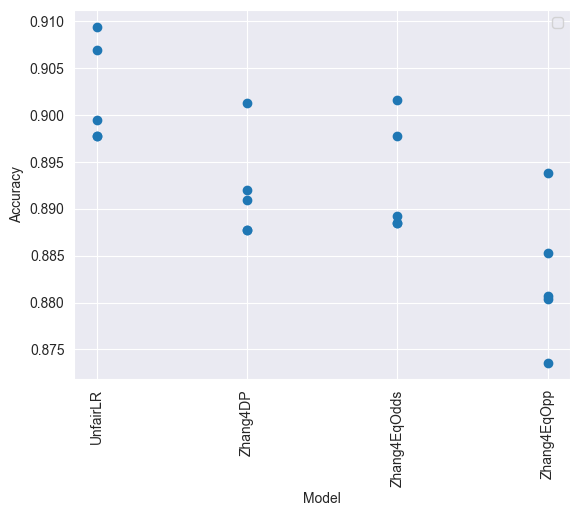

In [50]:
plt.plot()
plt.ylabel('Accuracy')

plt.scatter(model_names, model_accs)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Demographic Disparities

In [51]:
model_dps = unfair['dp'].to_list()+zhang['dp'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86056/2479496912.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


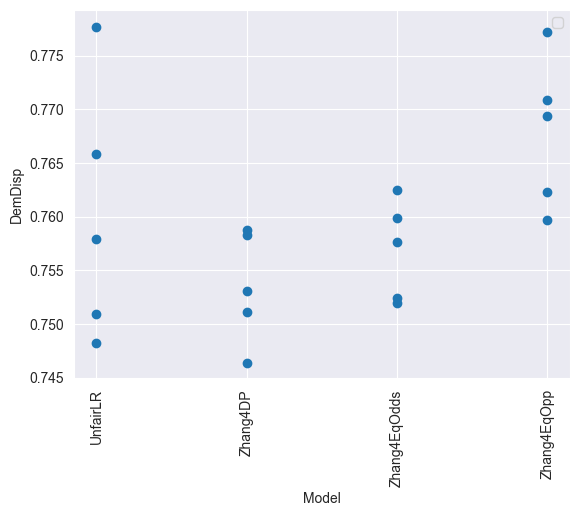

In [52]:
plt.plot()
plt.ylabel('DemDisp')

plt.scatter(model_names, model_dps)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Odds

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86056/1034882315.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


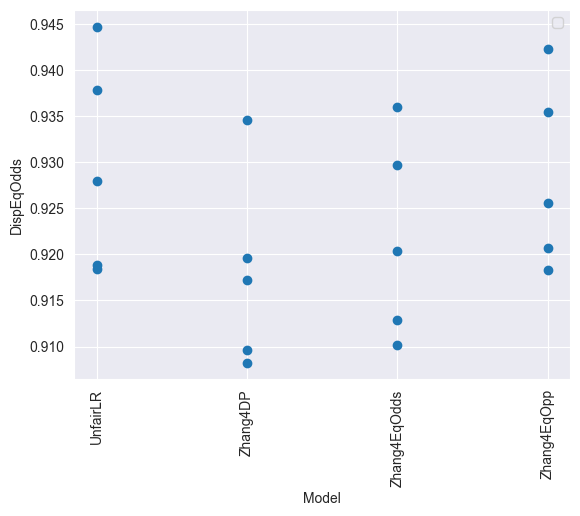

In [53]:
model_deqodds = unfair['deqodds'].to_list()+zhang['deqodds'].to_list()
plt.plot()
plt.ylabel('DispEqOdds')

plt.scatter(model_names, model_deqodds)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Opp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86056/755552296.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


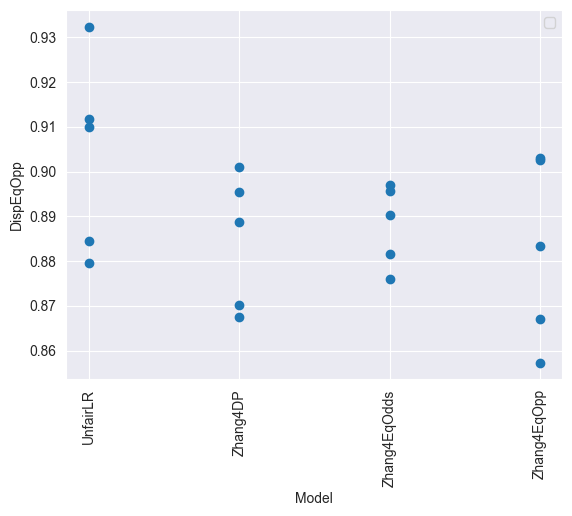

In [54]:
model_deqopps = unfair['deqopp'].to_list()+zhang['deqopp'].to_list()
plt.plot()
plt.ylabel('DispEqOpp')

plt.scatter(model_names, model_deqopps)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Trade-off Acc-DemDisp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86056/3481502659.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


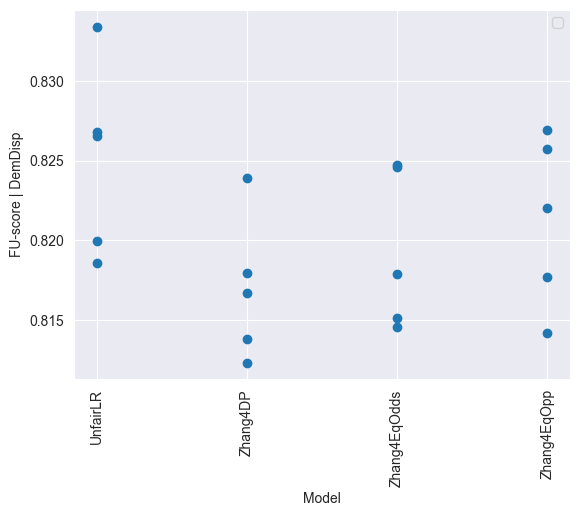

In [55]:
model_trade_dp = unfair['trade_dp'].to_list()+zhang['trade_dp'].to_list()
plt.plot()
plt.ylabel('FU-score | DemDisp')

plt.scatter(model_names, model_trade_dp)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Trade-off Acc-DispEqOdds

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86056/1478964109.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


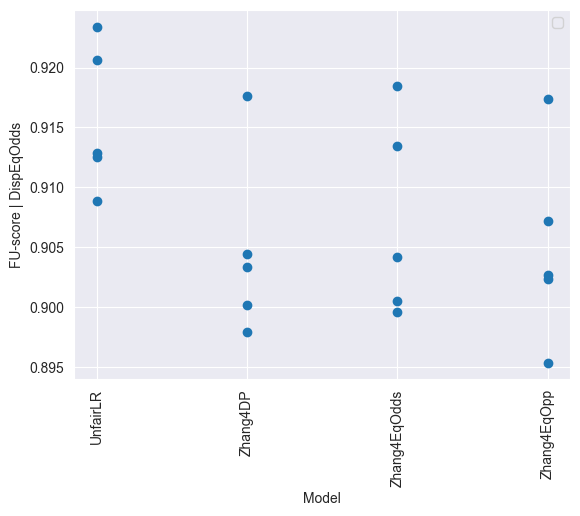

In [56]:
model_trade_deqodds = unfair['trade_deqodds'].to_list()+zhang['trade_deqodds'].to_list()
plt.plot()
plt.ylabel('FU-score | DispEqOdds')

plt.scatter(model_names, model_trade_deqodds)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Trade-off Acc-DispEqOpp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86056/1705168636.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


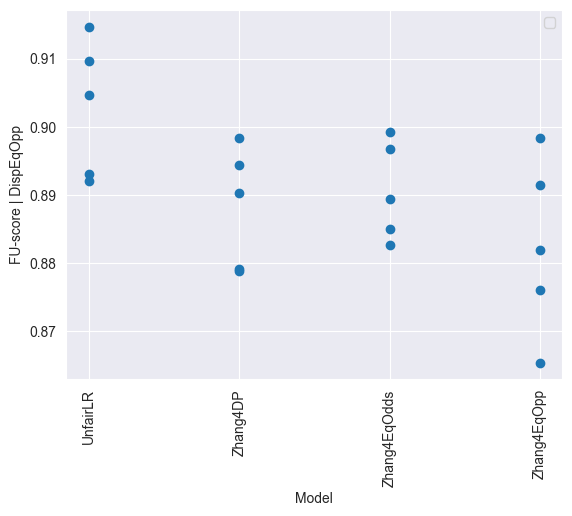

In [57]:
model_trade_deqopp = unfair['trade_deqopp'].to_list()+zhang['trade_deqopp'].to_list()
plt.plot()
plt.ylabel('FU-score | DispEqOpp')

plt.scatter(model_names, model_trade_deqopp)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Acc x DemDisp

In [58]:
'''cmap=sns.light_palette("seagreen")#,as_cmap=True)
cmap'''

'cmap=sns.light_palette("seagreen")#,as_cmap=True)\ncmap'

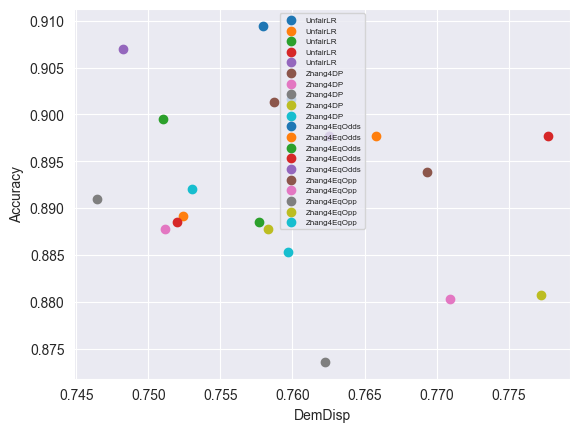

<Figure size 700x700 with 0 Axes>

In [59]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

plt.xlabel('DemDisp')
plt.ylabel('Accuracy')

for i, model_name in enumerate(model_names):
    plt.scatter(model_dps[i], model_accs[i], label=model_name)#, color=cmap[i])
plt.legend(loc='upper center', fontsize='xx-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x DispEqOdds

## Plotting Acc x DispEqOpp

# Pro artigo

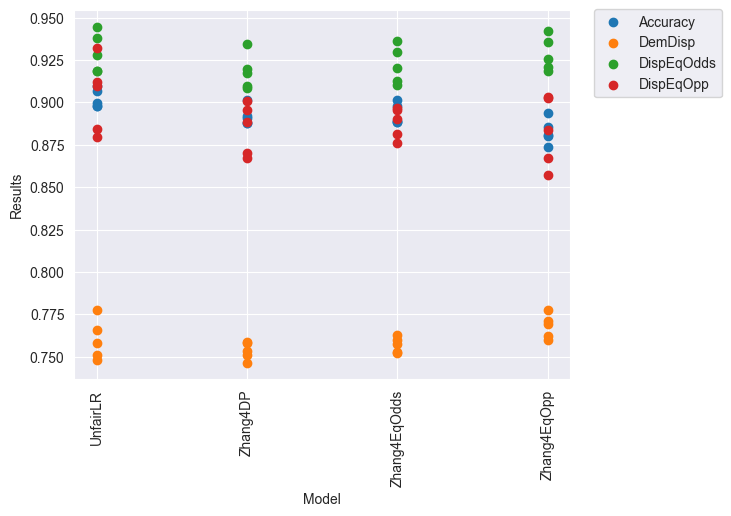

In [60]:

plt.plot()
plt.ylabel('Results')

plt.scatter(model_names, model_accs)
plt.scatter(model_names, model_dps)
plt.scatter(model_names, model_deqodds)
plt.scatter(model_names, model_deqopps)#, label = "ZHANG DemPar")


plt.xlabel('Model')
plt.xticks(rotation=90)
#plt.figure(figsize=(15,12))
#plt.yticks(range(0.755, 0.985))
#plt.yscale('log')
#plt.yticks([0.755, 0.80, 0.805, 0.81, 0.815, 0.82, 0.825, 0.83, 0.835, 0.84, 0.845, 0.85, 0.855, 0.86, 0.865, 0.87, 0.875, 0.88, 0.885, 0.89, 0.895, 0.90, 0.905, 0.91, 0.915, 0.92, 0.925, 0.93, 0.935, 0.94, 0.945, 0.95, 0.955, 0.96, 0.965, 0.97, 0.975,0.98, 0.985])
plt.legend(['Accuracy', 'DemDisp', 'DispEqOdds', 'DispEqOpp'], bbox_to_anchor=(1.32,1.02), loc="upper right")
plt.show()

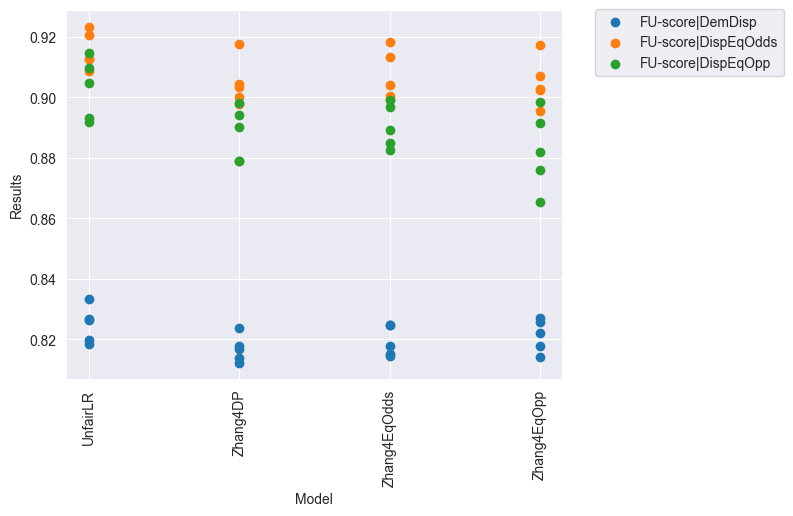

In [61]:

plt.plot()
plt.ylabel('Results')

plt.scatter(model_names, model_trade_dp)
plt.scatter(model_names, model_trade_deqodds)
plt.scatter(model_names, model_trade_deqopp)#, label = "ZHANG DemPar")


plt.xlabel('Model')
plt.xticks(rotation=90)
#plt.figure(figsize=(15,12))
#plt.yticks(range(0.755, 0.985))
#plt.yscale('log')
#plt.yticks([0.755, 0.80, 0.805, 0.81, 0.815, 0.82, 0.825, 0.83, 0.835, 0.84, 0.845, 0.85, 0.855, 0.86, 0.865, 0.87, 0.875, 0.88, 0.885, 0.89, 0.895, 0.90, 0.905, 0.91, 0.915, 0.92, 0.925, 0.93, 0.935, 0.94, 0.945, 0.95, 0.955, 0.96, 0.965, 0.97, 0.975,0.98, 0.985])
plt.legend(['FU-score|DemDisp', 'FU-score|DispEqOdds', 'FU-score|DispEqOpp'], bbox_to_anchor=(1.46,1.02), loc="upper right")
plt.show()